In [36]:
# import numpy as np
# import yaml

# from copy import deepcopy
# import numpy as np

# *from witch.cfg_loader import load_cfg

from witch.cfg_loader import load_cfg
from witch.fitter import *
from witch.objective import *

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
#Load in the data and models.
#TODO: right now this does some busy work loading the data and e.g. computing the noise map
#that it probably doesn't need to do if all you want to do is look at the model. Still it
#doesn't take very long and it's useful in other circumstances so I'm going to leave it in for the timebeing.

path = "/home/elebar/joint/WITCH/configs/xray_test/MOO1142_Xray.yaml"
cfg = load_config({}, path)
datasets, outdir, dset_names, metamodel = load_cfg(cfg)


Outputs can be found in /mnt/welch/USERS/elebar/Reductions/X_MOO1142/model_ns/first_try/r_1-beta-amp-P0-r_s-beta
Map scale:  2.7008111


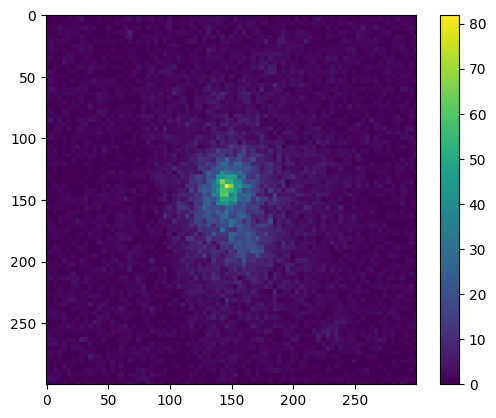

In [38]:
#plt.imshow(metamodel.datasets[0].metadata[0].beam_map)
#plt.colorbar()
#print(np.sum(metamodel.datasets[0].metadata[0].beam_map))

plt.imshow(datasets[0].datavec.solutions[0].data)
plt.colorbar()

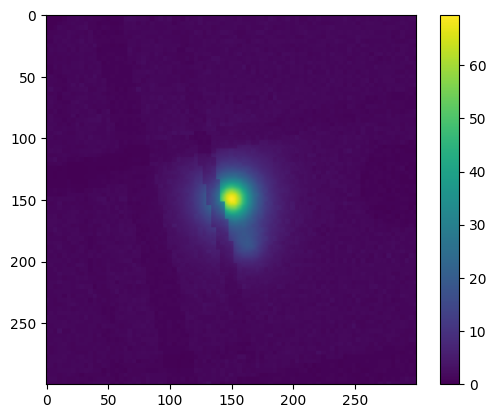

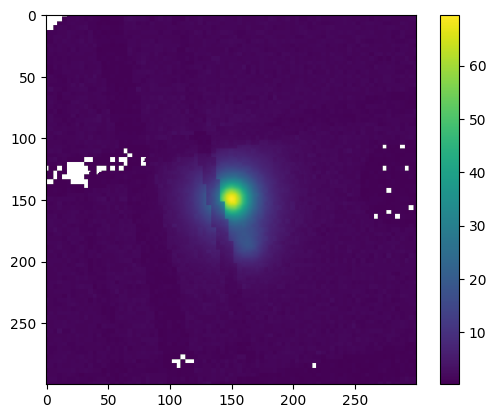

In [39]:
#To plot the full model on a given dataset, we use
#metamodel.model_grid(i), where i is the dataset of interest
#Plotting multiple datasets at the same time is in general non-sensical
#i.e. plotting x-ray and M2 simultaneously. However it can sometimes be 
#well defined (i.e. ACT+M2). In that case, you have to manually
# 1) get the maps in the same units 
# 2) get the maps in the same pixelation, probably by interpolation
#This is a pretty niche application so no example is given here
mask_map = np.where(metamodel.model_grid(0)>0.3, metamodel.model_grid(0), np.nan)
plt.imshow(metamodel.model_grid(0))
plt.colorbar()
plt.show()

plt.imshow(mask_map)
plt.colorbar()
plt.show()

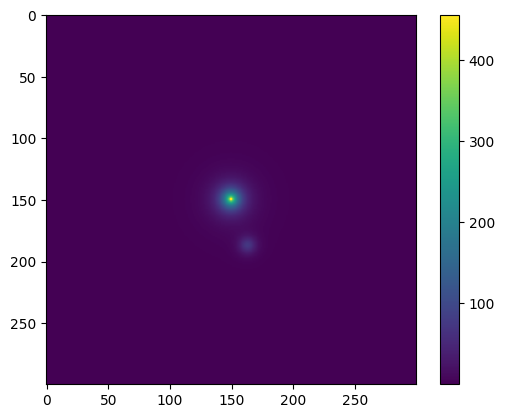

In [40]:
#If you want to only look at one component of the model, you can do the following:

plt.imshow(metamodel.models[0].model*metamodel.datasets[0].metadata[0].prefactor)
plt.colorbar()

In [41]:
#If you want to update parameters, do something like this

# pars = np.array(deepcopy(metamodel.parameters))
# pars[-1] = 1e-3

# metamodel.update(pars, metamodel.errors, metamodel.chisq)

# plt.imshow(metamodel.model_grid(0))
# plt.colorbar()

In [ ]:
@jax.jit
def stirling(map_data):
    safe_n = jnp.where(map_data == 0, 1.0, map_data)
    stirling_values = jnp.where(map_data == 0, 1.0, map_data * jnp.log(safe_n) - map_data)
    
    total_sum = jnp.nansum(stirling_values)
    
    return 2 * total_sum
npar = len(metamodel.parameters)
loglike = jnp.array(0)
grad = jnp.zeros(npar)
curve = jnp.zeros((npar, npar))
do_loglike = True
do_grad = True
do_curve = True
dataset_ind = 0

zero = jnp.zeros((1, 1))
only_loglike = not (do_grad or do_curve)

dataset = metamodel.datasets[dataset_ind]
if dataset.mode not in ["tod", "map"]:
    raise ValueError("Invalid mode")
for i, data in enumerate(dataset.datavec):
    pred_dat = metamodel.model_proj(dataset_ind, i)
    if only_loglike:
        grad_dat = zero
    else:
        grad_dat = metamodel.model_grad_proj(dataset_ind, i)

    #QUESTA RIGA VA CAMBIATA PERCHE I PIXEL 0/0 fanno inf
    #resid = (data.data /pred_dat) -1
    resid = (data.data - pred_dat) 
    mask_map = np.where(pred_dat>0.3, pred_dat, np.nan)
    if do_loglike:
        c0 = int(stirling(data.data))
        loglike += 0.5*( jnp.nansum(mask_map - data.data*jnp.log(mask_map)) + c0 )
        #loglike += jnp.sum(    data.data * jnp.log(pred_dat) - pred_dat - jnp.log(factorial(data.data))

    if only_loglike:
        continue

    grad_filt = jnp.zeros_like(grad_dat)
    for i in range(npar):
        grad_filt = grad_filt.at[i].set(
            data.noise.apply_noise(grad_dat.at[i].get())
        )
    grad_filt = jnp.reshape(grad_filt, (npar, -1))
    grad_dat = jnp.reshape(grad_dat, (npar, -1))
    resid = resid.ravel()

    if do_grad:
        grad = grad.at[:].add(jnp.dot(grad_dat, jnp.transpose(resid)))
    if do_curve:
        # Dropping the second term here, so Jon note for justification
        curve = curve.at[:].add(
            jnp.dot(
                -1 * grad_dat * (data.data / (pred_dat**2)).ravel(),
                jnp.transpose(grad_dat),
            )
        )
print("LOGLIKELIHOOD: {}", 2 * loglike)
print('GRAD {}', -2*grad)      

c0 471202
18633.04672736875
58035.90091338902
LOGLIKELIHOOD: {} 529237.900913389
GRAD {} [      -0.               -0.               -0.            15233.36837805
       -0.          -104230.17301133    42205.82835077       -0.
       -0.               -0.           857164.50277338   265303.10386731
       -0.               -0.         -1114655.46354179       -0.        ]


In [43]:
def stirling(n):
    if n == 0:
        return 1
    else:
        return n*np.log(n)-n

stirling = np.vectorize(stirling)

c0 = 2*np.nansum(stirling(datasets[0].datavec.solutions[0].data))
c0

np.int64(470930)

In [44]:
@jax.jit
def jax_stirling_pipeline(map_data):
    safe_n = jnp.where(map_data == 0, 1.0, map_data)
    stirling_values = jnp.where(map_data == 0, 1.0, map_data * jnp.log(safe_n) - map_data)
    
    total_sum = jnp.nansum(stirling_values)
    
    return 2 * total_sum

jax_stirling_pipeline(datasets[0].datavec.solutions[0].data)
int(jax_stirling_pipeline(datasets[0].datavec.solutions[0].data))



471202

In [45]:
chisq, *_ = joint_objective(metamodel)

471209.34375
-inf
nan
LOGLIKELIHOOD: nan
GRAD [      -0.               -0.               -0.            15233.36837805
       -0.          -104230.17301133    42205.82835077       -0.
       -0.               -0.           857164.50277338   265303.10386731
       -0.               -0.         -1114655.46354179       -0.        ]
